# Yield Curve EDA — Batch 1

Explores the US Treasury yield curve as a key driver in the FABN portfolio context.  
Data source: FRED rates stored in `data/bloomberg_first_batch_cleaned.xlsx → Treasury_Curve`  
Tenors: 1M, 3M, 6M, 1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 20Y, 30Y  
Date range: 2024-03-01 → 2026-02-26

**Sections:**
1. Load & inspect
2. Level / slope / curvature time series
3. Curve snapshots & shape over time
4. PCA factor decomposition
5. Regime classification
6. G-spread vs yield curve factors

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

DATA_PATH = '../data/bloomberg_first_batch_cleaned.xlsx'
SPREAD_PATH = '../arthur_data/daily_spread.csv'
BOND_PATH = '../arthur_data/bond_universe.csv'

## 1. Load & Inspect

In [2]:
# ── Treasury curve ──────────────────────────────────────────────────────────
raw = pd.read_excel(DATA_PATH, sheet_name='Treasury_Curve', index_col=0, parse_dates=True)

# Columns come in as floats (years); rename to readable labels
tenor_map = {
    0.08333333333333333: '1M',
    0.25:  '3M',
    0.5:   '6M',
    1:     '1Y',
    2:     '2Y',
    3:     '3Y',
    5:     '5Y',
    7:     '7Y',
    10:    '10Y',
    20:    '20Y',
    30:    '30Y',
}
curve = raw.rename(columns=tenor_map)
curve.index.name = 'date'
curve.sort_index(inplace=True)

TENORS = list(tenor_map.values())   # ordered short → long
TENOR_YEARS = list(tenor_map.keys())

print(f'Shape: {curve.shape}')
print(f'Date range: {curve.index.min().date()} → {curve.index.max().date()}')
print(f'Tenors: {TENORS}')
curve.tail(3)

Shape: (520, 11)
Date range: 2024-03-01 → 2026-02-26
Tenors: ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']


,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
date,,,,,,,,,,,
2026-02-24,3.72,3.69,3.62,3.52,3.43,3.47,3.61,3.81,4.04,4.63,4.70
2026-02-25,3.71,3.69,3.62,3.53,3.45,3.49,3.61,3.82,4.05,4.63,4.70
2026-02-26,3.74,3.68,3.61,3.52,3.42,3.46,3.57,3.78,4.02,4.60,4.67


In [3]:
# Basic stats
curve.describe().round(2)

,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
count,520.00,520.00,520.00,520.00,520.00,520.00,520.00,520.00,520.00,520.00,520.00
mean,4.62,4.55,4.41,4.19,4.02,3.96,4.00,4.12,4.26,4.67,4.63
std,0.59,0.60,0.58,0.52,0.44,0.38,0.31,0.26,0.22,0.21,0.24
min,3.65,3.62,3.56,3.40,3.40,3.42,3.41,3.51,3.63,4.01,3.94
25%,4.24,4.25,4.03,3.83,3.60,3.61,3.72,3.92,4.13,4.56,4.48
50%,4.40,4.37,4.30,4.12,3.94,3.89,3.98,4.12,4.26,4.69,4.69
75%,5.40,5.21,4.88,4.37,4.29,4.28,4.25,4.29,4.41,4.82,4.82
max,5.56,5.52,5.44,5.25,5.04,4.87,4.72,4.71,4.79,5.08,5.08


In [4]:
# Missing data check
missing = curve.isnull().sum()
print('Missing values per tenor:')
print(missing)

Missing values per tenor:
1M     0
3M     0
6M     0
1Y     0
2Y     0
3Y     0
5Y     0
7Y     0
10Y    0
20Y    0
30Y    0
dtype: int64


## 2. Level / Slope / Curvature Time Series

Three simple summary statistics that capture the dominant curve dynamics:

| Metric | Definition | Interpretation |
|--------|-----------|----------------|
| **Level** | 10Y yield | Overall rate environment |
| **Slope** | 10Y − 2Y | Steepness; negative = inverted |
| **Curvature** | 2×5Y − (2Y + 10Y) | Belly richness vs wings |

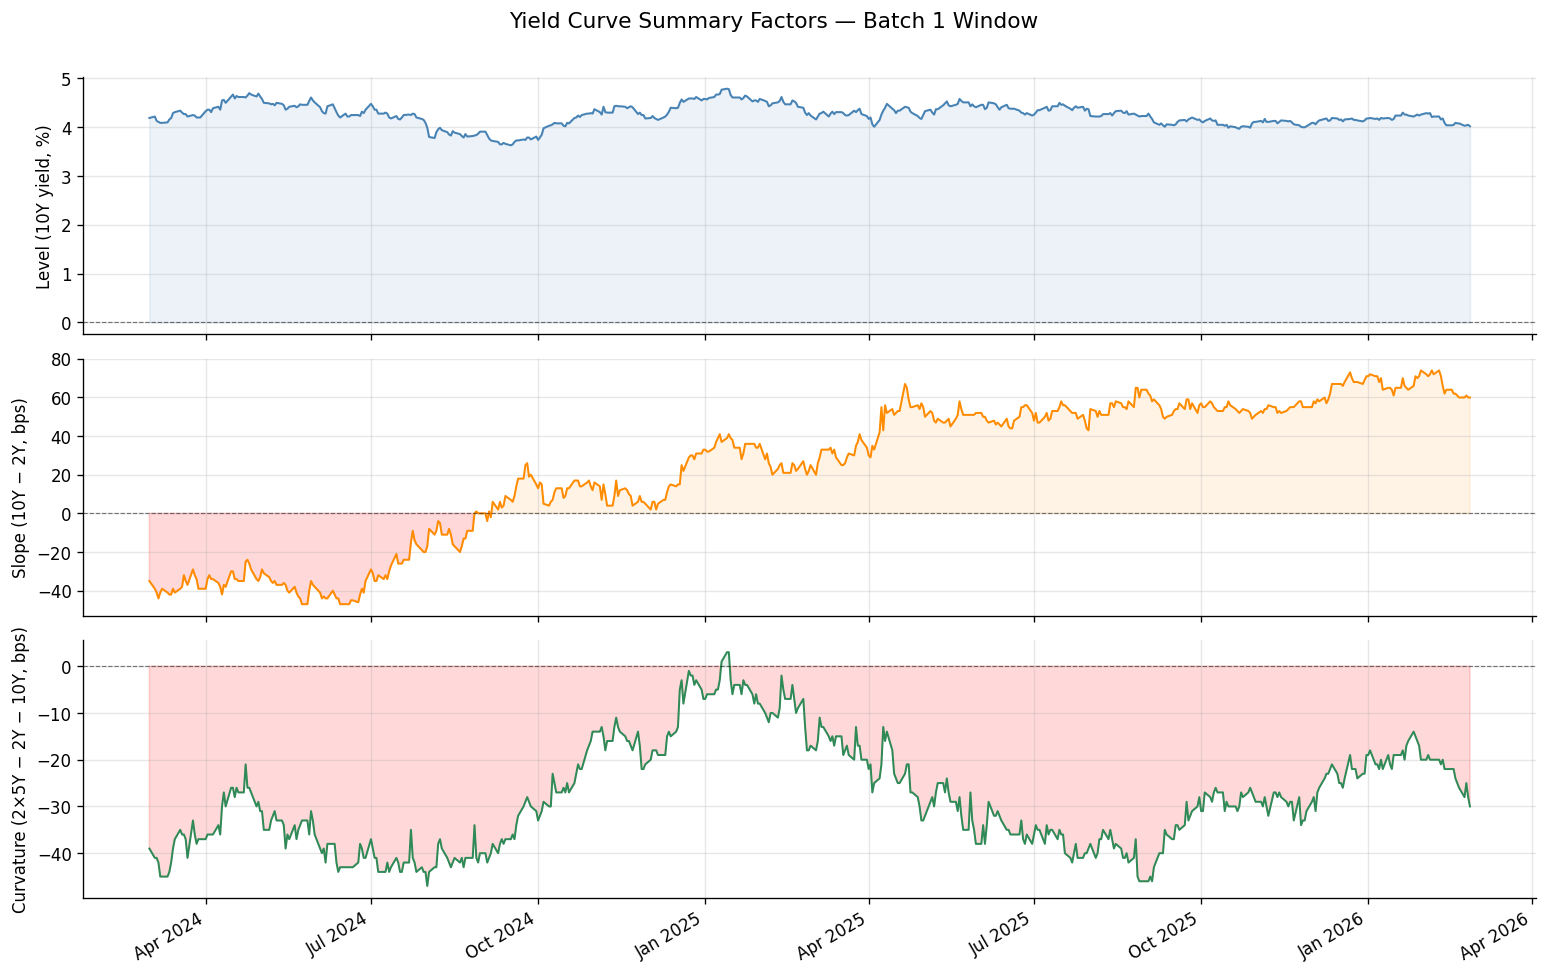

          level     slope  curvature
count  520.0000  520.0000   520.0000
mean     4.2557    0.2369    -0.2797
std      0.2193    0.3670     0.1128
min      3.6300   -0.4700    -0.4700
25%      4.1300    0.0000    -0.3700
50%      4.2600    0.3300    -0.2900
75%      4.4100    0.5400    -0.2000
max      4.7900    0.7400     0.0300


In [5]:
factors = pd.DataFrame(index=curve.index)
factors['level']      = curve['10Y']
factors['slope']      = curve['10Y'] - curve['2Y']   # positive = normal, negative = inverted
factors['curvature']  = 2 * curve['5Y'] - (curve['2Y'] + curve['10Y'])  # positive = hump

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
colors = ['steelblue', 'darkorange', 'seagreen']
labels = ['Level (10Y yield, %)', 'Slope (10Y − 2Y, bps)', 'Curvature (2×5Y − 2Y − 10Y, bps)']
scales = [1, 100, 100]  # convert slope/curvature to bps

for ax, col, color, label, scale in zip(axes, ['level', 'slope', 'curvature'], colors, labels, scales):
    series = factors[col] * scale
    ax.plot(series.index, series, color=color, linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
    ax.set_ylabel(label, fontsize=10)
    ax.fill_between(series.index, series, 0,
                    where=(series < 0), color='red', alpha=0.15, label='Inverted / negative')
    ax.fill_between(series.index, series, 0,
                    where=(series >= 0), color=color, alpha=0.1)

axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=30)
fig.suptitle('Yield Curve Summary Factors — Batch 1 Window', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(factors.describe().round(4))

In [6]:
# Mark regime transitions
factors['inverted'] = factors['slope'] < 0
pct_inverted = factors['inverted'].mean() * 100
print(f'Fraction of days with inverted curve (10Y < 2Y): {pct_inverted:.1f}%')

# First inversion end
inversion_end = factors[~factors['inverted']].index.min()
print(f'Curve first un-inverted: {inversion_end.date()}')

Fraction of days with inverted curve (10Y < 2Y): 24.8%
Curve first un-inverted: 2024-08-27


## 3. Curve Snapshots & Shape Over Time

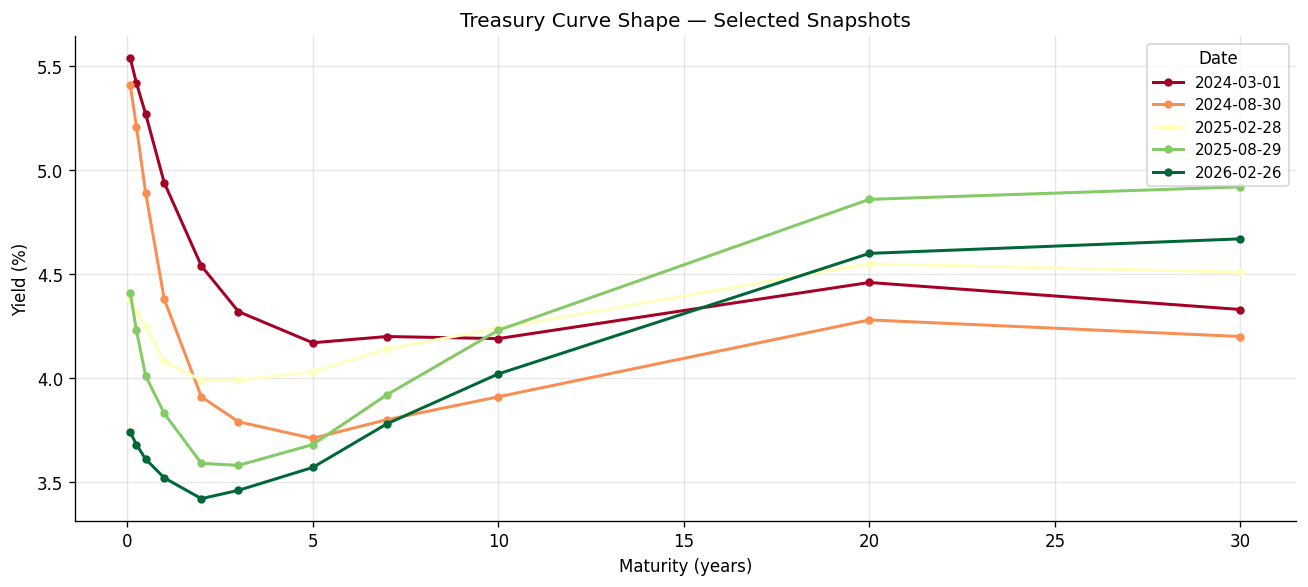

In [7]:
# Snapshot: first, middle, last date in window + key events
snapshot_dates = [
    curve.index[0],
    curve.index[len(curve)//4],
    curve.index[len(curve)//2],
    curve.index[3*len(curve)//4],
    curve.index[-1],
]

fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.cm.RdYlGn
norm = Normalize(vmin=0, vmax=len(snapshot_dates) - 1)

for i, d in enumerate(snapshot_dates):
    row = curve.loc[d]
    ax.plot(TENOR_YEARS, row.values, marker='o', markersize=4,
            color=cmap(norm(i)), linewidth=1.8,
            label=d.strftime('%Y-%m-%d'))

ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Yield (%)')
ax.set_title('Treasury Curve Shape — Selected Snapshots', fontsize=12)
ax.legend(title='Date', fontsize=9)
plt.tight_layout()
plt.show()

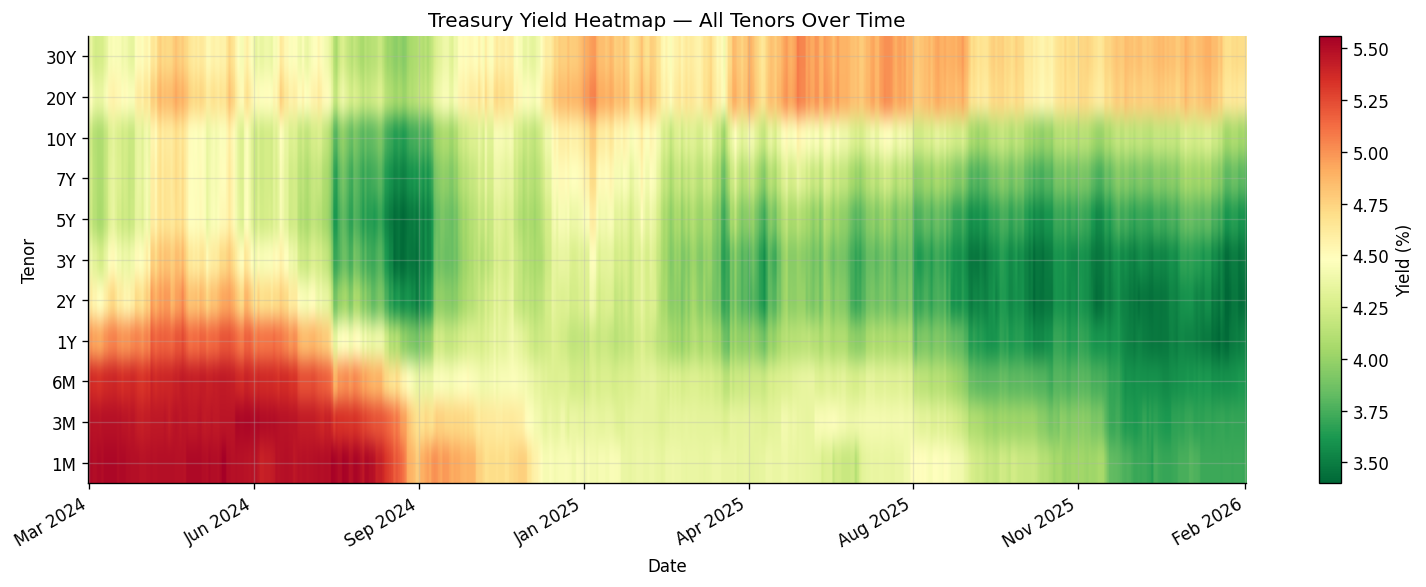

In [8]:
# Heatmap: all tenors over time
fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(
    curve[TENORS].T.values,
    aspect='auto',
    cmap='RdYlGn_r',
    origin='lower'
)

# x-axis: date labels
n = len(curve)
tick_positions = np.linspace(0, n-1, 8, dtype=int)
tick_labels = [curve.index[i].strftime('%b %Y') for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=30, ha='right')

# y-axis: tenor labels
ax.set_yticks(range(len(TENORS)))
ax.set_yticklabels(TENORS)

plt.colorbar(im, ax=ax, label='Yield (%)')
ax.set_title('Treasury Yield Heatmap — All Tenors Over Time', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Tenor')
plt.tight_layout()
plt.show()

## 4. PCA Factor Decomposition

PCA on daily **changes** in yield (not levels) reveals the orthogonal movements that actually drive rate risk:
- PC1 ≈ Level (parallel shift)
- PC2 ≈ Slope (steepening/flattening)
- PC3 ≈ Curvature (butterfly)

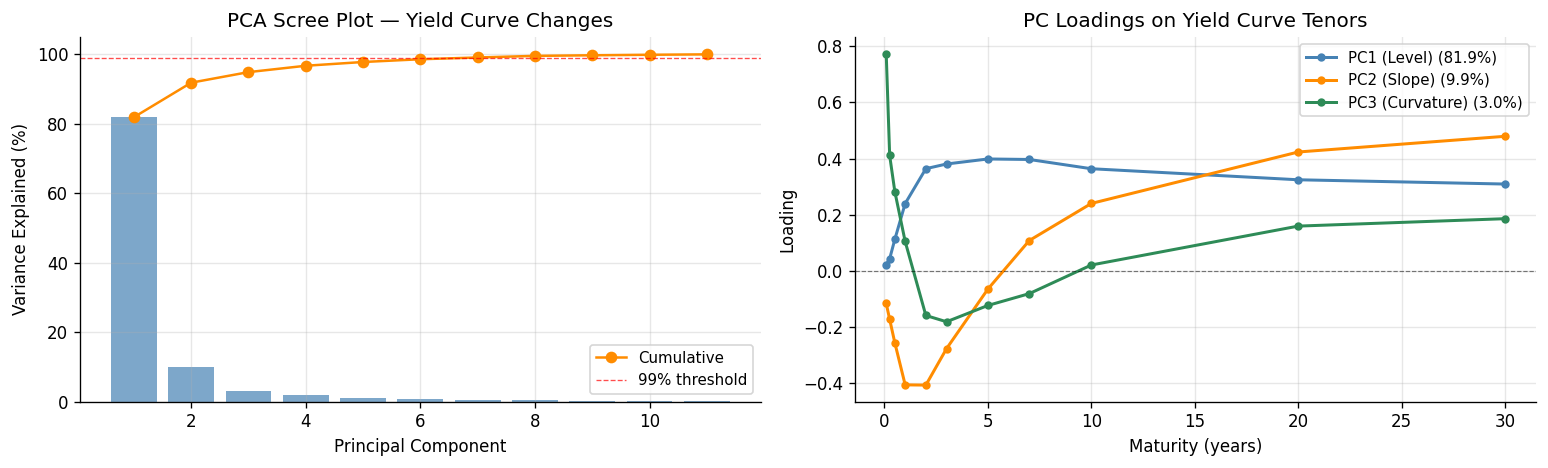

Variance explained:
  PC1: 81.89%  (cumulative: 81.89%)
  PC2: 9.95%  (cumulative: 91.84%)
  PC3: 3.04%  (cumulative: 94.88%)


In [9]:
# Daily changes in yield (bps)
dy = curve[TENORS].diff().dropna() * 100  # convert % → bps

pca = PCA()
pca.fit(dy)

var_explained = pca.explained_variance_ratio_
cum_var = np.cumsum(var_explained)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
ax = axes[0]
ax.bar(range(1, len(var_explained)+1), var_explained * 100, color='steelblue', alpha=0.7)
ax.plot(range(1, len(var_explained)+1), cum_var * 100, 'o-', color='darkorange', linewidth=1.5, label='Cumulative')
ax.axhline(99, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='99% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('PCA Scree Plot — Yield Curve Changes')
ax.legend(fontsize=9)

# Factor loadings (first 3 PCs)
ax = axes[1]
colors_pc = ['steelblue', 'darkorange', 'seagreen']
for i, (color, label) in enumerate(zip(colors_pc, ['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)'])):
    ax.plot(TENOR_YEARS, pca.components_[i], marker='o', markersize=4,
            color=color, linewidth=1.8, label=f'{label} ({var_explained[i]*100:.1f}%)')
ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Loading')
ax.set_title('PC Loadings on Yield Curve Tenors')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Variance explained:')
for i in range(3):
    print(f'  PC{i+1}: {var_explained[i]*100:.2f}%  (cumulative: {cum_var[i]*100:.2f}%)')

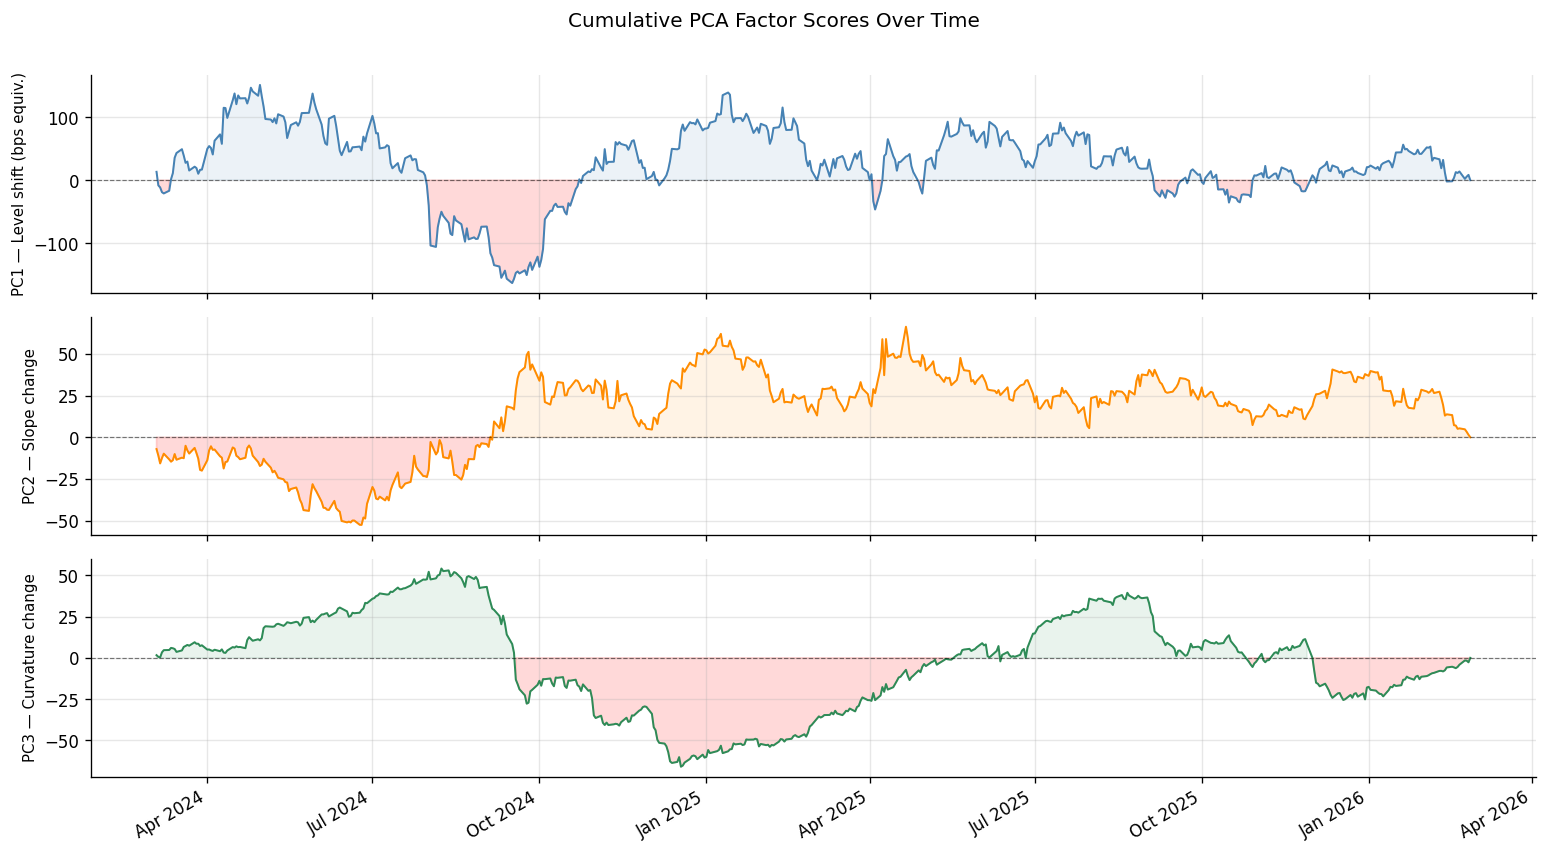

In [10]:
# Project yield changes onto PCA factors → daily PC scores
pc_scores = pd.DataFrame(
    pca.transform(dy),
    index=dy.index,
    columns=[f'PC{i+1}' for i in range(dy.shape[1])]
)

# Rolling cumulative scores (shows regime shifts)
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
pc_labels = ['PC1 — Level shift (bps equiv.)', 'PC2 — Slope change', 'PC3 — Curvature change']
for ax, col, label, color in zip(axes, ['PC1', 'PC2', 'PC3'], pc_labels, colors_pc):
    cumulative = pc_scores[col].cumsum()
    ax.plot(cumulative.index, cumulative, color=color, linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
    ax.fill_between(cumulative.index, cumulative, 0,
                    where=(cumulative >= 0), color=color, alpha=0.1)
    ax.fill_between(cumulative.index, cumulative, 0,
                    where=(cumulative < 0), color='red', alpha=0.15)
    ax.set_ylabel(label, fontsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=30)
fig.suptitle('Cumulative PCA Factor Scores Over Time', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

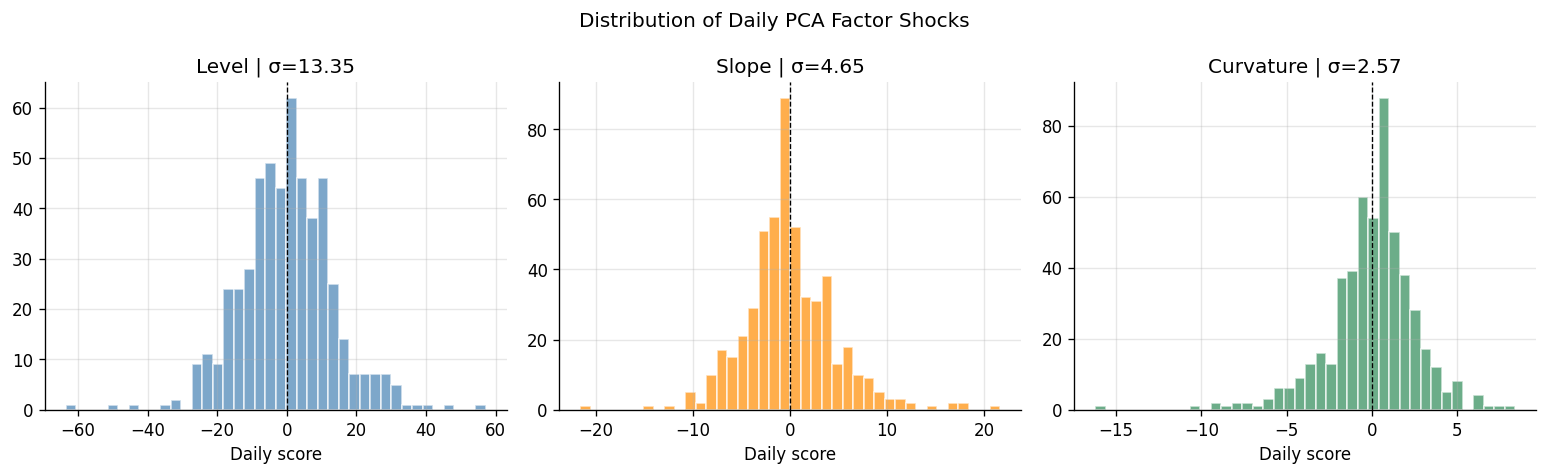

Daily PC score stats (bps equivalent):
           PC1      PC2      PC3
count  519.000  519.000  519.000
mean     0.000    0.000   -0.000
std     13.354    4.654    2.575
min    -63.499  -21.580  -16.231
25%     -7.921   -2.450   -1.165
50%      0.326   -0.459    0.285
75%      8.210    2.561    1.417
max     57.182   21.681    8.382


In [11]:
# Daily PC score distributions
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, color, label in zip(axes, ['PC1', 'PC2', 'PC3'], colors_pc, ['Level', 'Slope', 'Curvature']):
    ax.hist(pc_scores[col], bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{label} (PC{["1","2","3"][["PC1","PC2","PC3"].index(col)]})')
    ax.set_xlabel('Daily score')
    std = pc_scores[col].std()
    ax.set_title(f'{label} | σ={std:.2f}')

fig.suptitle('Distribution of Daily PCA Factor Shocks', fontsize=12)
plt.tight_layout()
plt.show()

print('Daily PC score stats (bps equivalent):')
print(pc_scores[['PC1', 'PC2', 'PC3']].describe().round(3))

## 5. Regime Classification

Classify each day's curve shape into regimes using slope (10Y−2Y) and level (10Y).  
Also run k-means on the full curve shape to let the data define regimes.

In [12]:
# Rule-based regime: slope threshold
slope_bps = factors['slope'] * 100

def classify_regime(slope):
    if slope < -25:
        return 'Deeply Inverted'
    elif slope < 0:
        return 'Mildly Inverted'
    elif slope < 50:
        return 'Flat / Normalizing'
    else:
        return 'Normal / Steep'

factors['regime'] = slope_bps.apply(classify_regime)

regime_counts = factors['regime'].value_counts()
print('Rule-based regime distribution:')
print(regime_counts)
print(f'\nAs fraction of total trading days:')
print((regime_counts / len(factors)).round(3))

Rule-based regime distribution:
regime
Normal / Steep        198
Flat / Normalizing    193
Deeply Inverted        97
Mildly Inverted        32
Name: count, dtype: int64

As fraction of total trading days:
regime
Normal / Steep        0.381
Flat / Normalizing    0.371
Deeply Inverted       0.187
Mildly Inverted       0.062
Name: count, dtype: float64


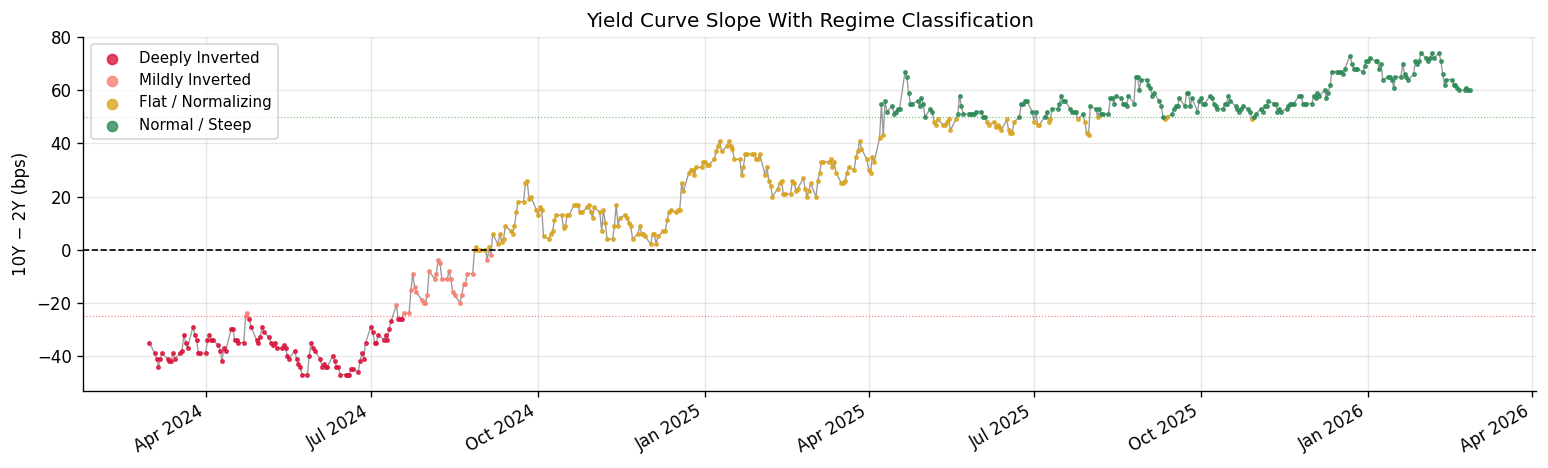

In [13]:
# Plot slope time series colored by regime
regime_colors = {
    'Deeply Inverted':    'crimson',
    'Mildly Inverted':    'salmon',
    'Flat / Normalizing': 'goldenrod',
    'Normal / Steep':     'seagreen',
}

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(slope_bps.index, slope_bps, color='black', linewidth=0.8, alpha=0.4, zorder=1)

for regime, color in regime_colors.items():
    mask = factors['regime'] == regime
    ax.scatter(slope_bps.index[mask], slope_bps[mask], s=4, color=color,
               label=regime, zorder=2, alpha=0.8)

ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.axhline(-25, color='red', linewidth=0.7, linestyle=':', alpha=0.5)
ax.axhline(50, color='green', linewidth=0.7, linestyle=':', alpha=0.5)
ax.set_ylabel('10Y − 2Y (bps)')
ax.set_title('Yield Curve Slope With Regime Classification', fontsize=12)
ax.legend(fontsize=9, markerscale=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

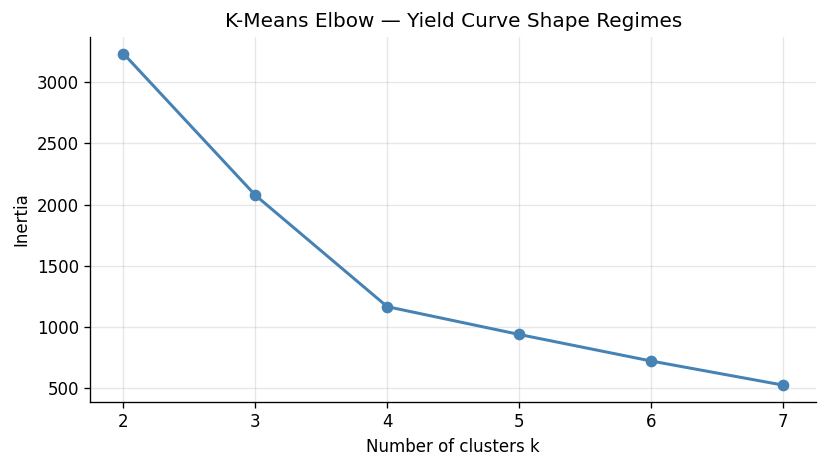

In [14]:
# K-means on curve levels (let the data define clusters)
X_levels = curve[TENORS].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_levels)

# Elbow plot
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, 'o-', color='steelblue', linewidth=1.8)
ax.set_xlabel('Number of clusters k')
ax.set_ylabel('Inertia')
ax.set_title('K-Means Elbow — Yield Curve Shape Regimes')
plt.tight_layout()
plt.show()

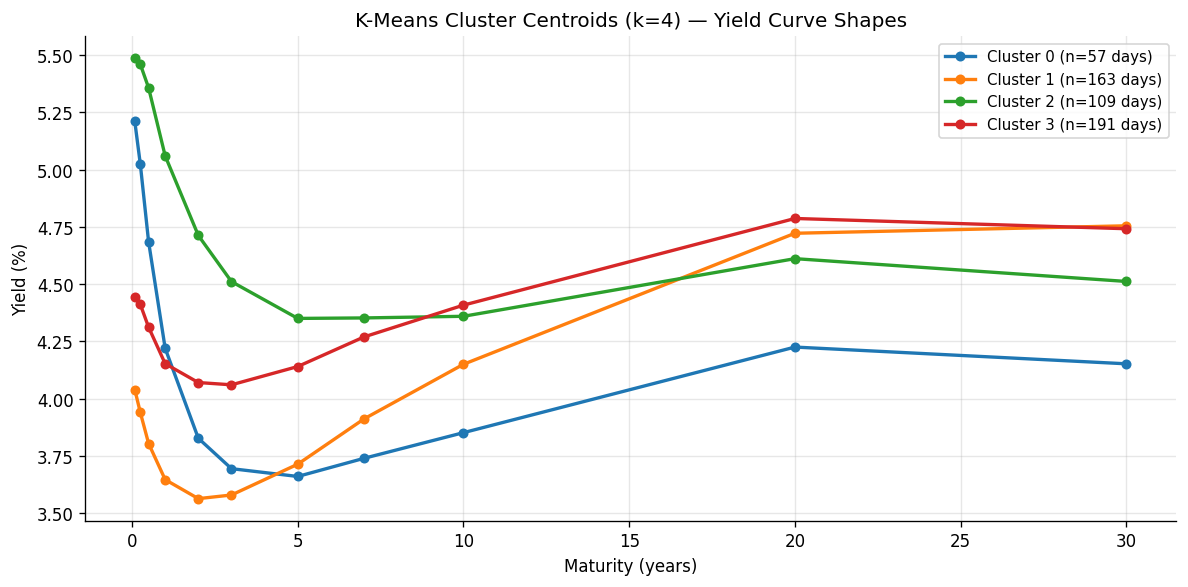

In [15]:
# Fit k=4 clusters (adjust after reviewing elbow)
K_BEST = 4
km4 = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
km4.fit(X_scaled)

kmeans_labels = pd.Series(km4.labels_, index=X_levels.index, name='kmeans_regime')
factors['kmeans_regime'] = kmeans_labels

# Plot cluster centroids as curve shapes
centroids_orig = scaler.inverse_transform(km4.cluster_centers_)

fig, ax = plt.subplots(figsize=(10, 5))
cmap_k = plt.cm.tab10
for k in range(K_BEST):
    count = (kmeans_labels == k).sum()
    ax.plot(TENOR_YEARS, centroids_orig[k],
            marker='o', markersize=5, linewidth=2,
            color=cmap_k(k),
            label=f'Cluster {k} (n={count} days)')

ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Yield (%)')
ax.set_title(f'K-Means Cluster Centroids (k={K_BEST}) — Yield Curve Shapes', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

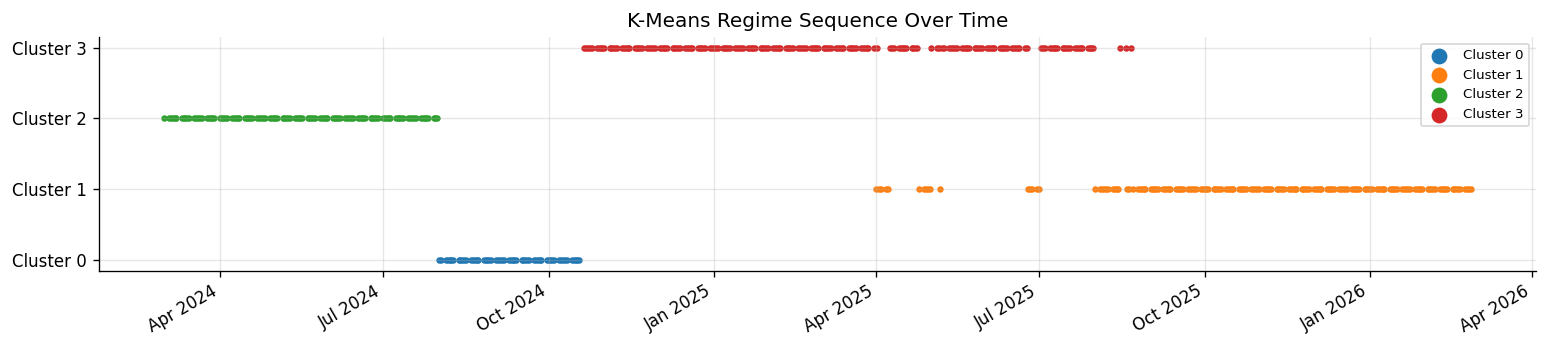

In [16]:
# K-means regimes over time
fig, ax = plt.subplots(figsize=(13, 3))
for k in range(K_BEST):
    mask = kmeans_labels == k
    ax.scatter(kmeans_labels.index[mask],
               [k] * mask.sum(),
               s=8, color=cmap_k(k), label=f'Cluster {k}')

ax.set_yticks(range(K_BEST))
ax.set_yticklabels([f'Cluster {k}' for k in range(K_BEST)])
ax.set_title('K-Means Regime Sequence Over Time', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=8, markerscale=3, loc='upper right')
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

## 6. G-Spread vs Yield Curve Factors

Do G-spreads co-move with the yield curve?  
Regress daily spread changes on the 3 PCA factor shocks.

In [17]:
# Load G-spreads (already in bps from daily_spread.csv)
spreads = pd.read_csv(SPREAD_PATH, index_col=0, parse_dates=True)
spreads.sort_index(inplace=True)

# Align with curve data window
common_idx = dy.index.intersection(spreads.index)
ds = spreads.loc[common_idx].diff().dropna()  # daily spread changes
pc = pc_scores.loc[ds.index]                  # aligned PC scores

print(f'Aligned observations: {len(ds)}')
print(f'Bonds: {ds.shape[1]}')
spreads.describe().round(1)

Aligned observations: 497
Bonds: 104


,00139PAA6,EC5379283,04685A3R0,04686E3X8,04685A2P5,04686E2R2,05964HAS4,06407EAE5,06407F2E1,13607HVE9,...,92857WAB6,929089AB6,949746TB7,961214ET6,96122XAQ1,96122WAQ3,96122QAC7,96122FAC1,96122QAA1,96122FAA5
count,499.0,499.0,499.0,499.0,499.0,499.0,499.0,499.0,499.0,499.0,...,499.0,499.0,499.0,499.0,499.0,499.0,499.0,499.0,499.0,499.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,...,0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
25%,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,...,0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


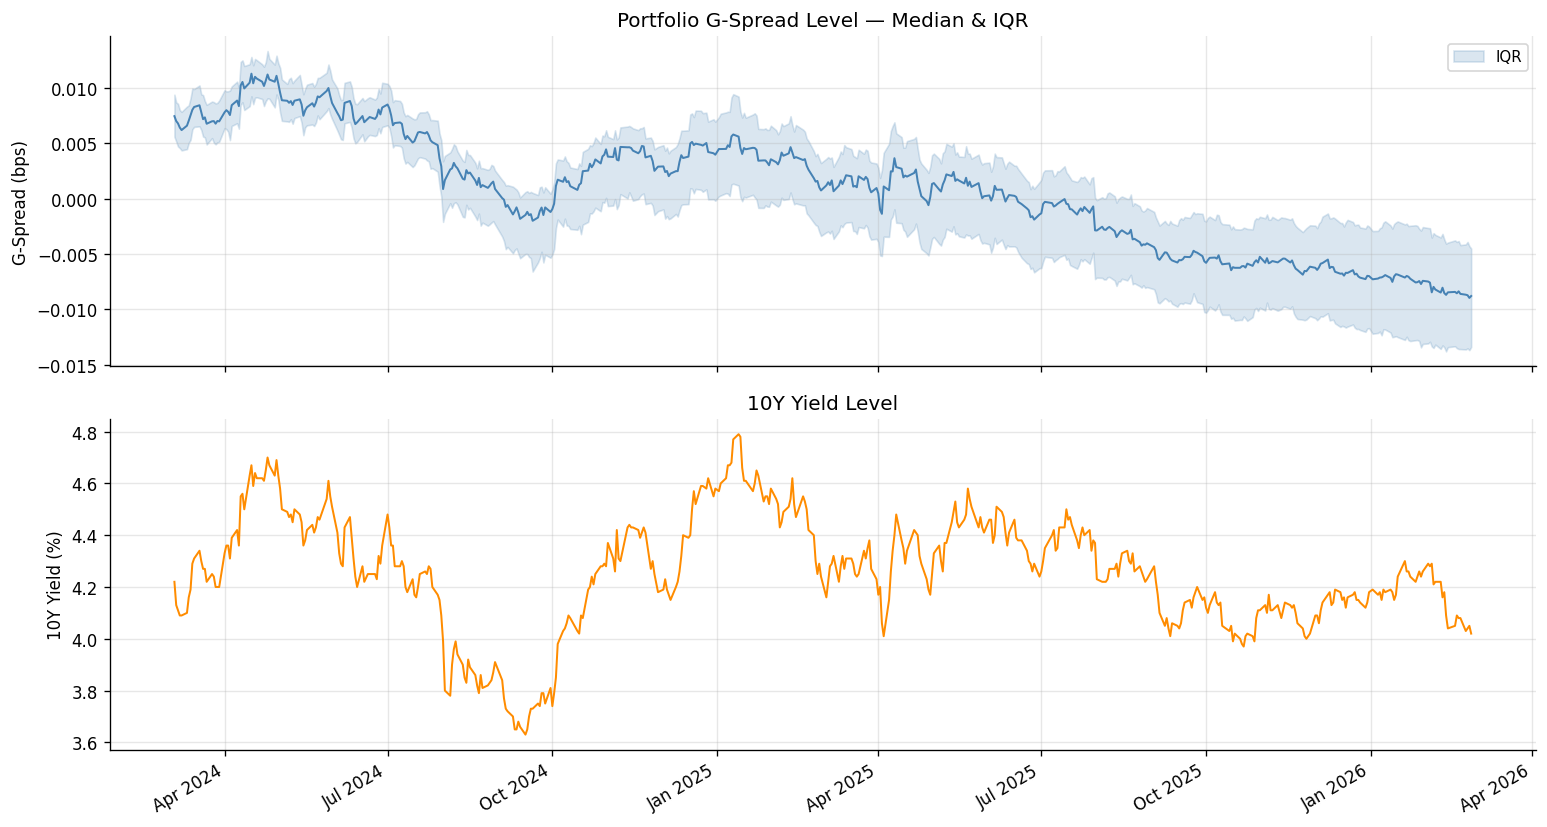

Correlation: median G-spread vs 10Y yield level = 0.494


In [18]:
# Cross-sectional median spread level over time
median_spread = spreads.loc[common_idx].median(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(median_spread.index, median_spread, color='steelblue', linewidth=1.2)
axes[0].fill_between(median_spread.index,
                     spreads.loc[common_idx].quantile(0.25, axis=1),
                     spreads.loc[common_idx].quantile(0.75, axis=1),
                     color='steelblue', alpha=0.2, label='IQR')
axes[0].set_ylabel('G-Spread (bps)')
axes[0].set_title('Portfolio G-Spread Level — Median & IQR')
axes[0].legend(fontsize=9)

axes[1].plot(factors.loc[common_idx, 'level'].index,
             factors.loc[common_idx, 'level'],
             color='darkorange', linewidth=1.2)
axes[1].set_ylabel('10Y Yield (%)')
axes[1].set_title('10Y Yield Level')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

corr = median_spread.corr(factors.loc[common_idx, 'level'])
print(f'Correlation: median G-spread vs 10Y yield level = {corr:.3f}')

In [19]:
from scipy.stats import linregress

# Per-bond OLS regression: ΔSpread_i ~ β0 + β1*PC1 + β2*PC2 + β3*PC3
results = []
for bond in ds.columns:
    y = ds[bond].dropna()
    X = pc.loc[y.index, ['PC1', 'PC2', 'PC3']]
    common = y.index.intersection(X.index)
    if len(common) < 50:
        continue
    y_ = y.loc[common].values
    X_ = np.column_stack([np.ones(len(common)), X.loc[common].values])
    try:
        betas, _, _, _ = np.linalg.lstsq(X_, y_, rcond=None)
        ss_res = np.sum((y_ - X_ @ betas) ** 2)
        ss_tot = np.sum((y_ - y_.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        results.append({
            'bond': bond,
            'beta_level': betas[1],
            'beta_slope': betas[2],
            'beta_curv':  betas[3],
            'r2': r2,
            'n': len(common),
        })
    except Exception:
        pass

reg = pd.DataFrame(results).set_index('bond')
print(f'Bonds with regression: {len(reg)}')
reg.describe().round(4)

Bonds with regression: 104


,beta_level,beta_slope,beta_curv,r2,n
count,104.0,104.0,104.0,104.0000,104.0
mean,0.0,0.0,-0.0,0.0380,497.0
std,0.0,0.0,0.0,0.0165,0.0
min,-0.0,-0.0,-0.0,0.0011,497.0
25%,0.0,0.0,-0.0,0.0268,497.0
50%,0.0,0.0,-0.0,0.0383,497.0
75%,0.0,0.0,-0.0,0.0515,497.0
max,0.0,0.0,0.0,0.0684,497.0


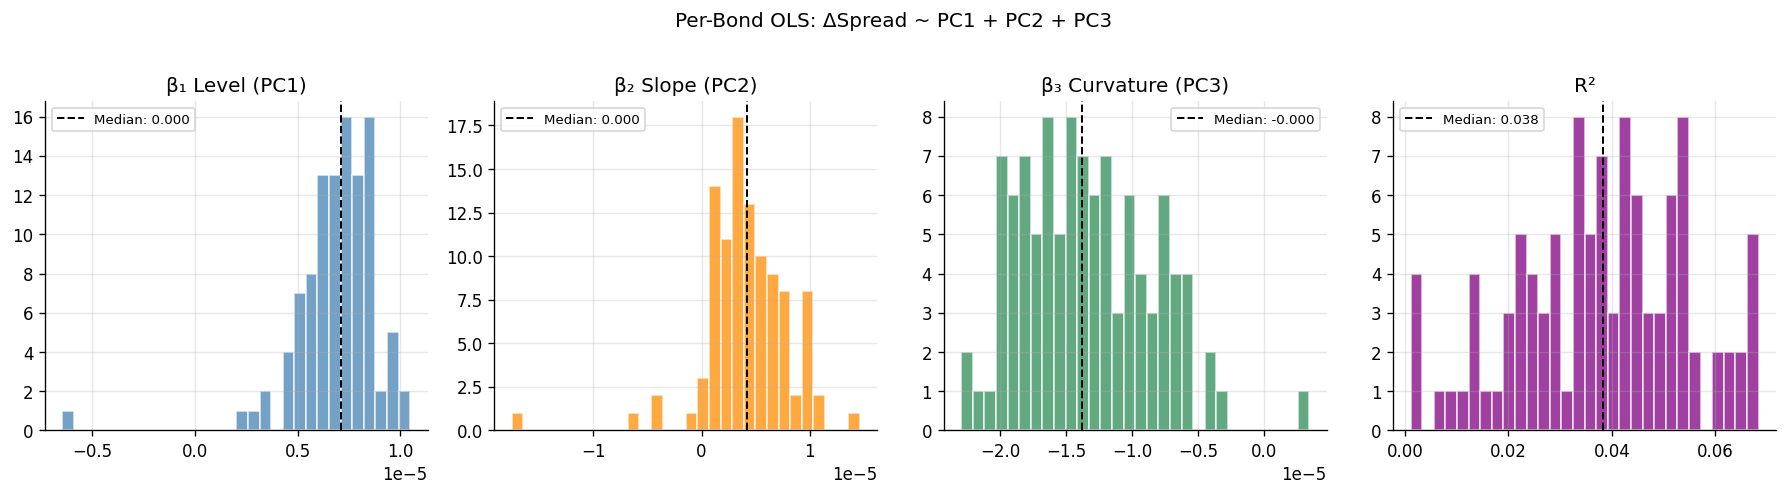


Median betas across bonds:
beta_level    0.0000
beta_slope    0.0000
beta_curv    -0.0000
r2            0.0383
dtype: float64


In [20]:
# Distribution of betas and R²
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
plot_cols = ['beta_level', 'beta_slope', 'beta_curv', 'r2']
plot_labels = ['β₁ Level (PC1)', 'β₂ Slope (PC2)', 'β₃ Curvature (PC3)', 'R²']
plot_colors = ['steelblue', 'darkorange', 'seagreen', 'purple']

for ax, col, label, color in zip(axes, plot_cols, plot_labels, plot_colors):
    ax.hist(reg[col].dropna(), bins=30, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(reg[col].median(), color='black', linewidth=1.2, linestyle='--',
               label=f'Median: {reg[col].median():.3f}')
    ax.set_title(label)
    ax.legend(fontsize=8)

fig.suptitle('Per-Bond OLS: ΔSpread ~ PC1 + PC2 + PC3', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('\nMedian betas across bonds:')
print(reg[['beta_level', 'beta_slope', 'beta_curv', 'r2']].median().round(4))

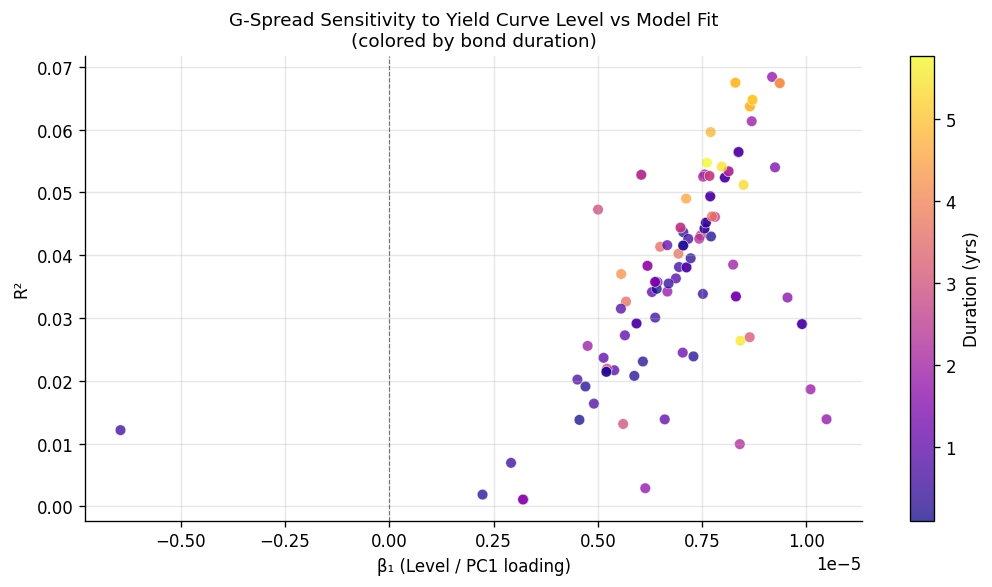

In [21]:
# Scatter: beta_level vs R² — do rate-sensitive bonds have better predictability?
bond_universe = pd.read_csv(BOND_PATH)
bond_universe.set_index('CUSIP', inplace=True)

reg_augmented = reg.join(bond_universe[['duration', 'BBG Composite', 'BICS_LEVEL_1_SECTOR_NAME']], how='left')

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    reg_augmented['beta_level'],
    reg_augmented['r2'],
    c=reg_augmented['duration'],
    cmap='plasma',
    s=40, alpha=0.75, edgecolors='white', linewidths=0.3
)
plt.colorbar(sc, ax=ax, label='Duration (yrs)')
ax.axvline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
ax.set_xlabel('β₁ (Level / PC1 loading)')
ax.set_ylabel('R²')
ax.set_title('G-Spread Sensitivity to Yield Curve Level vs Model Fit\n(colored by bond duration)', fontsize=11)
plt.tight_layout()
plt.show()

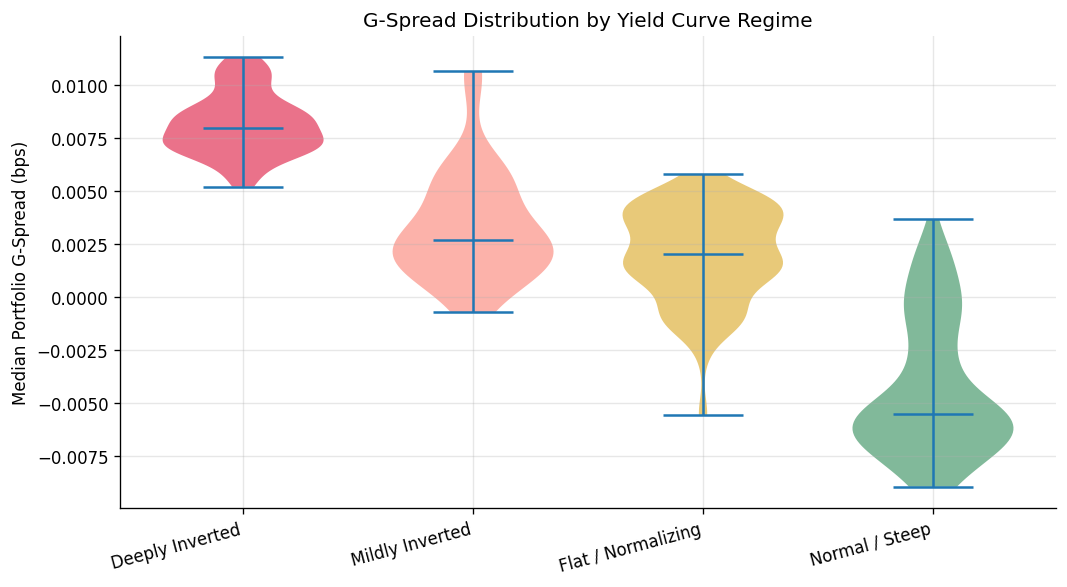


Median G-spread by regime (bps):
                    median  std  count
regime                                
Deeply Inverted        0.0  0.0     94
Flat / Normalizing     0.0  0.0    183
Mildly Inverted        0.0  0.0     32
Normal / Steep        -0.0  0.0    189


In [22]:
# G-spread dispersion by regime
spread_level = spreads.loc[common_idx].median(axis=1)
spread_level.name = 'median_spread'
regime_spread = pd.concat([spread_level, factors.loc[common_idx, 'regime']], axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
regime_order = ['Deeply Inverted', 'Mildly Inverted', 'Flat / Normalizing', 'Normal / Steep']
regime_palette = ['crimson', 'salmon', 'goldenrod', 'seagreen']

parts = ax.violinplot(
    [regime_spread.loc[regime_spread['regime'] == r, 'median_spread'].dropna().values
     for r in regime_order],
    positions=range(len(regime_order)),
    showmedians=True,
    widths=0.7
)
for body, color in zip(parts['bodies'], regime_palette):
    body.set_facecolor(color)
    body.set_alpha(0.6)

ax.set_xticks(range(len(regime_order)))
ax.set_xticklabels(regime_order, rotation=15, ha='right')
ax.set_ylabel('Median Portfolio G-Spread (bps)')
ax.set_title('G-Spread Distribution by Yield Curve Regime', fontsize=12)
plt.tight_layout()
plt.show()

print('\nMedian G-spread by regime (bps):')
print(regime_spread.groupby('regime')['median_spread'].agg(['median', 'std', 'count']).round(1))